In [29]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_table('Fig1c_test.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,Mg,PC1,PC2,S470fs,top_peak,splice,N715A,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,38,-0.024919,0.024124,0,0,0,1,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,31,-0.017065,0.018734,0,0,0,1,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,31,-0.018403,0.018840,0,0,0,1,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,29,-0.029610,0.022555,0,0,0,1,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,36,-0.029266,0.026182,0,0,0,1,0.0,0.0,1.0


In [5]:
df.shape

(677, 54)

In [8]:
df_na=df.dropna()
df_na.shape

(552, 54)

In [9]:
df_filtered=df.drop(columns=['S470fs','top_peak','splice','N715A'])

In [10]:
df_filtered=df_filtered.dropna()
df_filtered.shape

(552, 50)

In [11]:
df_filtered.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,CaCO3,N,P,K,Mg,PC1,PC2,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,11.829166,...,56.835339,1.240112,36.844051,226.204865,38,-0.024919,0.024124,0.0,0.0,1.0
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,11.100000,...,38.288258,2.772524,44.490234,201.766663,31,-0.017065,0.018734,0.0,0.0,1.0
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,11.100000,...,38.288258,2.772524,44.490234,201.766663,31,-0.018403,0.018840,0.0,0.0,1.0
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,9.325000,...,25.146477,2.195257,25.737415,143.398697,29,-0.029610,0.022555,0.0,0.0,1.0
4,350,TOU-A1-88,France,46.6667,4.116670,CS77382,leaf,France_leaf,5189.422620,10.720833,...,0.782203,1.743629,36.619621,237.669601,36,-0.029266,0.026182,0.0,0.0,1.0


In [90]:
X=df_filtered.drop(columns=['Chr5_282011'])
y=df_filtered['Chr5_282011']

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [102]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Mg25','Accession_ID','Latitude','Longitude','Chr5_21390834','Chr5_21392702'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
99,7.783333,6.833333,28.954802,643.835571,21.100000,-2.5,23.600000,4.650000,2.666667,15.966667,...,5.988177,14.969644,9.420408,6.893508,1.767194,34.157993,112.461731,37,-0.003062,-0.062278
577,14.375000,11.266666,36.699242,695.999939,32.099998,1.4,30.699999,10.216667,23.316666,23.516666,...,7.039402,9.917389,11.263844,143.233261,1.404741,23.023563,410.993897,63,0.030154,0.048431
110,3.191667,7.950000,26.411959,801.920532,19.500000,-10.6,30.100000,8.616667,-2.700000,13.550000,...,4.223059,21.625450,13.204588,10.963806,3.857980,32.582630,175.875122,28,0.039146,-0.065792
122,7.429167,6.941667,29.665243,617.971252,21.000000,-2.4,23.400000,8.100000,2.416667,15.400001,...,4.277642,17.420004,15.510866,0.000000,2.269231,32.850574,113.173950,40,-0.021087,-0.019192
322,3.720833,7.425000,25.871080,765.005798,19.400000,-9.3,28.700001,4.083333,2.083333,13.766666,...,4.417257,22.941128,10.247595,3.081563,1.817570,31.159666,200.911102,37,0.082064,-0.115854


In [103]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Mg25','Accession_ID','Latitude','Longitude','Chr5_21390834','Chr5_21392702'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
166,7.708333,8.133333,30.012300,732.172485,22.600000,-4.5,27.100000,15.166666,0.016667,16.650000,...,5.705269,16.058172,11.157388,25.958227,3.301706,34.523438,147.622986,45,-0.040188,-0.018114
632,13.483334,8.616667,34.605087,595.446106,27.299999,2.4,24.900000,10.133333,21.100000,21.100000,...,7.682940,10.851852,16.795162,241.994827,1.877531,27.121227,569.941650,41,-0.017303,0.022547
672,8.887500,8.875000,33.874046,661.778320,23.400000,-2.8,26.199999,15.516666,2.033333,17.116667,...,6.501186,14.220779,21.088411,25.370443,1.627157,13.001573,177.099808,44,-0.035168,0.008550
514,8.829166,8.875000,33.745247,661.820679,23.400000,-2.9,26.299999,15.483334,1.983333,17.083334,...,6.777113,10.793190,24.431425,19.516340,2.853489,25.356667,213.628357,46,-0.033460,0.007953
598,10.629167,10.458333,37.086288,628.159119,27.200001,-1.0,28.200001,7.100000,18.766666,18.766666,...,6.131900,10.578207,17.065409,49.823498,1.780894,36.731995,142.317673,24,0.016028,0.035929


In [104]:
header=X_train.columns.to_list()
print(header)

['bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'wind', 'srad', 'ai', 'awc', 'bulk_density', 'clay', 'coarse_frag', 'sand', 'silt', 'ph', 'CN', 'CEC', 'CaCO3', 'N', 'P', 'K', 'Mg', 'PC1', 'PC2']


In [105]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_train = pd.DataFrame(X_train,columns=header)
X_test = sc.transform(X_test)
X_test = pd.DataFrame(X_test,columns=header)

In [106]:
from sklearn.model_selection import GridSearchCV

parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200],
           'criterion' :['gini', 'entropy']}
forest_model= RandomForestClassifier(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=3)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'max_leaf_nodes': 9, 'n_estimators': 200}
0.8480725623582765


In [107]:
y_pred=forest_model_cv.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('accuracy score:', round(accuracy, 3))
print(f1_score(y_test, y_pred))

accuracy score: 0.802
0.8842105263157896


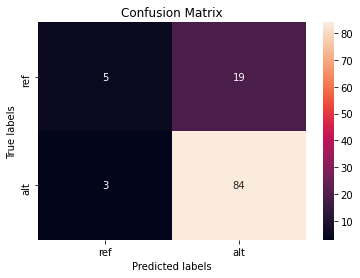

In [108]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['ref', 'alt']); ax.yaxis.set_ticklabels(['ref', 'alt']) 
    plt.show() 
plot_confusion_matrix(y_test,y_pred)

In [109]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 5 19]
 [ 3 84]]


In [110]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    forest_model_cv, X_test, y_test, n_repeats=100, random_state=0, n_jobs=4
)
# elapsed_time = time.time() - start_time
# print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

model_importances = pd.Series(result.importances_mean, index=X_train.columns)

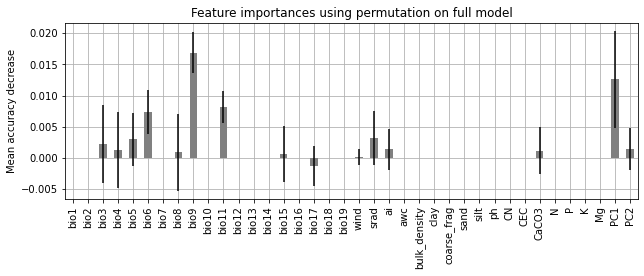

In [111]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c.pdf", format="pdf",bbox_inches="tight",facecolor="w")